In [69]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report
from sklearn.preprocessing import StandardScaler


In [35]:
df = pd.read_csv(r"E:\Machine Learning\Customer Churn Prediction\data\app_user_churn.csv")
df.head()

,Age,Tenure_Months,Monthly_Charges,Total_Charges,Support_Calls,Data_Usage_GB,Num_Devices,Satisfaction_Score,Payment_Delay_Days,Monthly_App_Sessions,Avg_Session_Duration_Min,Last_Login_Days_Ago,App_Crash_Count,Notification_Complaints,Features_Used,Competitor_Usage_Hours,Contract_Length,Internet_Service,Payment_Method,Churn
0,58.0,15.0,19.13,267.58,3.0,21.36,1.0,5.0,2.0,38.0,39.1,3.0,2.0,3.0,4.0,25.3,Monthly,NaN,Debit Card,0
1,62.0,70.0,84.22,NaN,4.0,121.51,1.0,2.0,22.0,28.0,31.9,19.0,6.0,5.0,2.0,4.6,Monthly,DSL,Bank Transfer,0
2,69.0,6.0,135.41,821.29,6.0,12.28,3.0,NaN,28.0,56.0,33.8,24.0,2.0,0.0,11.0,11.4,One Year,Fiber,Debit Card,0
3,42.0,36.0,89.81,3557.23,2.0,55.84,2.0,3.0,NaN,60.0,62.2,9.0,5.0,8.0,12.0,12.2,One Year,DSL,Bank Transfer,0
4,58.0,72.0,51.24,3494.80,12.0,116.51,2.0,1.0,25.0,21.0,37.3,8.0,6.0,9.0,15.0,35.9,Monthly,NaN,Digital Wallet,1


In [36]:
df.shape

(3520, 20)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3520 entries, 0 to 3519
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3388 non-null   float64
 1   Tenure_Months             3387 non-null   float64
 2   Monthly_Charges           3384 non-null   float64
 3   Total_Charges             3371 non-null   float64
 4   Support_Calls             3377 non-null   float64
 5   Data_Usage_GB             3389 non-null   float64
 6   Num_Devices               3400 non-null   float64
 7   Satisfaction_Score        3389 non-null   float64
 8   Payment_Delay_Days        3383 non-null   float64
 9   Monthly_App_Sessions      3388 non-null   float64
 10  Avg_Session_Duration_Min  3359 non-null   float64
 11  Last_Login_Days_Ago       3394 non-null   float64
 12  App_Crash_Count           3372 non-null   float64
 13  Notification_Complaints   3392 non-null   float64
 14  Features

In [38]:
df.describe()

,Age,Tenure_Months,Monthly_Charges,Total_Charges,Support_Calls,Data_Usage_GB,Num_Devices,Satisfaction_Score,Payment_Delay_Days,Monthly_App_Sessions,Avg_Session_Duration_Min,Last_Login_Days_Ago,App_Crash_Count,Notification_Complaints,Features_Used,Competitor_Usage_Hours,Churn
count,3388.000000,3387.000000,3384.000000,3371.000000,3377.00000,3389.000000,3400.000000,3389.000000,3383.000000,3388.000000,3359.000000,3394.000000,3372.000000,3392.000000,3396.000000,3380.000000,3520.000000
mean,44.626033,37.092117,98.840115,3610.307081,6.07403,77.480929,4.021176,2.977870,15.051138,29.797816,46.625097,45.553035,7.623369,5.269458,8.026796,25.238136,0.506534
std,15.712309,20.692338,57.929183,2898.189968,3.74045,54.650531,2.001358,1.398192,9.055486,17.213096,29.741541,28.369966,6.085753,4.301787,4.311732,14.826964,0.500028
min,18.000000,1.000000,15.010000,21.390000,0.00000,0.520000,1.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,31.000000,19.000000,55.780000,1245.595000,3.00000,38.680000,2.000000,2.000000,7.000000,15.000000,23.250000,23.000000,3.000000,2.000000,4.000000,12.700000,0.000000
50%,45.000000,37.000000,95.635000,2826.180000,6.00000,75.570000,4.000000,3.000000,15.000000,29.000000,45.700000,45.000000,7.000000,5.000000,8.000000,25.000000,1.000000
75%,58.000000,55.000000,139.690000,5348.915000,9.00000,112.540000,6.000000,4.000000,23.000000,45.000000,68.250000,68.000000,11.000000,8.000000,12.000000,37.600000,1.000000
max,105.000000,72.000000,750.000000,14493.350000,12.00000,800.000000,7.000000,5.000000,30.000000,60.000000,400.000000,365.000000,100.000000,80.000000,15.000000,150.000000,1.000000


In [39]:
df.isna().sum()

Age                          132
Tenure_Months                133
Monthly_Charges              136
Total_Charges                149
Support_Calls                143
Data_Usage_GB                131
Num_Devices                  120
Satisfaction_Score           131
Payment_Delay_Days           137
Monthly_App_Sessions         132
Avg_Session_Duration_Min     161
Last_Login_Days_Ago          126
App_Crash_Count              148
Notification_Complaints      128
Features_Used                124
Competitor_Usage_Hours       140
Contract_Length              134
Internet_Service            1260
Payment_Method               140
Churn                          0
dtype: int64

In [40]:
null_percentage = (df.isnull().sum() / len(df)) * 100
null_percentage

Age                          3.750000
Tenure_Months                3.778409
Monthly_Charges              3.863636
Total_Charges                4.232955
Support_Calls                4.062500
Data_Usage_GB                3.721591
Num_Devices                  3.409091
Satisfaction_Score           3.721591
Payment_Delay_Days           3.892045
Monthly_App_Sessions         3.750000
Avg_Session_Duration_Min     4.573864
Last_Login_Days_Ago          3.579545
App_Crash_Count              4.204545
Notification_Complaints      3.636364
Features_Used                3.522727
Competitor_Usage_Hours       3.977273
Contract_Length              3.806818
Internet_Service            35.795455
Payment_Method               3.977273
Churn                        0.000000
dtype: float64

In [41]:
df.duplicated().sum()

20

In [42]:
df.drop_duplicates(inplace=True)

In [43]:
df.duplicated().sum()

0

In [44]:
df.dtypes

Age                         float64
Tenure_Months               float64
Monthly_Charges             float64
Total_Charges               float64
Support_Calls               float64
Data_Usage_GB               float64
Num_Devices                 float64
Satisfaction_Score          float64
Payment_Delay_Days          float64
Monthly_App_Sessions        float64
Avg_Session_Duration_Min    float64
Last_Login_Days_Ago         float64
App_Crash_Count             float64
Notification_Complaints     float64
Features_Used               float64
Competitor_Usage_Hours      float64
Contract_Length              object
Internet_Service             object
Payment_Method               object
Churn                         int64
dtype: object

In [45]:
df.select_dtypes(include="object").columns

Index(['Contract_Length', 'Internet_Service', 'Payment_Method'], dtype='object')

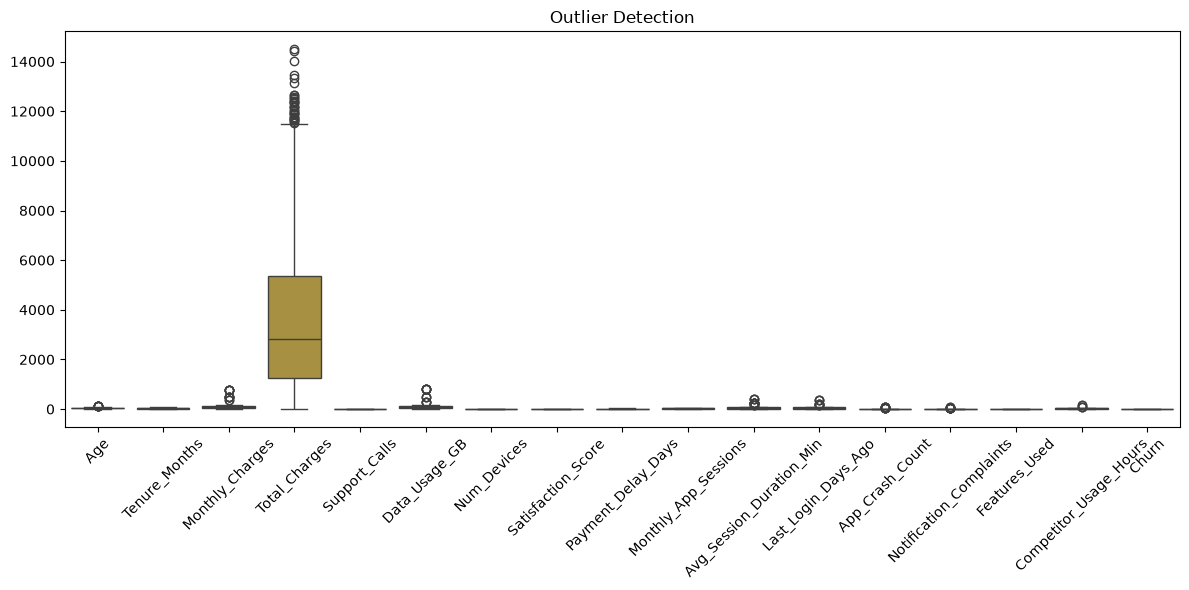

In [46]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df.select_dtypes(include=np.number))

plt.xticks(rotation=45)
plt.title("Outlier Detection")

plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=300, bbox_inches='tight')
plt.show()

In [47]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

In [48]:
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [49]:
categorical_columns

Index(['Contract_Length', 'Internet_Service', 'Payment_Method'], dtype='object')

In [50]:
for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


Contract_Length
Contract_Length
One Year    1288
Two Year    1107
Monthly     1105
Name: count, dtype: int64

Internet_Service
Internet_Service
Fiber    2387
DSL      1113
Name: count, dtype: int64

Payment_Method
Payment_Method
Digital Wallet    1026
Bank Transfer      850
Credit Card        850
Debit Card         774
Name: count, dtype: int64


In [51]:
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True,dtype=int)

In [52]:
df.head()

,Age,Tenure_Months,Monthly_Charges,Total_Charges,Support_Calls,Data_Usage_GB,Num_Devices,Satisfaction_Score,Payment_Delay_Days,Monthly_App_Sessions,...,Notification_Complaints,Features_Used,Competitor_Usage_Hours,Churn,Contract_Length_One Year,Contract_Length_Two Year,Internet_Service_Fiber,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Digital Wallet
0,58.0,15.0,19.13,267.580,3.0,21.36,1.0,5.0,2.0,38.0,...,3.0,4.0,25.3,0,0,0,1,0,1,0
1,62.0,70.0,84.22,2831.035,4.0,121.51,1.0,2.0,22.0,28.0,...,5.0,2.0,4.6,0,0,0,0,0,0,0
2,69.0,6.0,135.41,821.290,6.0,12.28,3.0,3.0,28.0,56.0,...,0.0,11.0,11.4,0,1,0,1,0,1,0
3,42.0,36.0,89.81,3557.230,2.0,55.84,2.0,3.0,15.0,60.0,...,8.0,12.0,12.2,0,1,0,0,0,0,0
4,58.0,72.0,51.24,3494.800,12.0,116.51,2.0,1.0,25.0,21.0,...,9.0,15.0,35.9,1,0,0,1,0,0,1


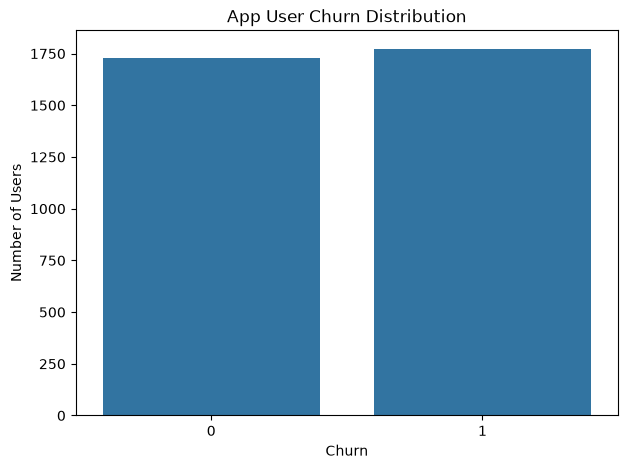

In [53]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.xlabel("Churn")
plt.ylabel("Number of Users")
plt.title("App User Churn Distribution")

plt.savefig('churn_distribution.png',dpi=300,bbox_inches='tight')
plt.show()

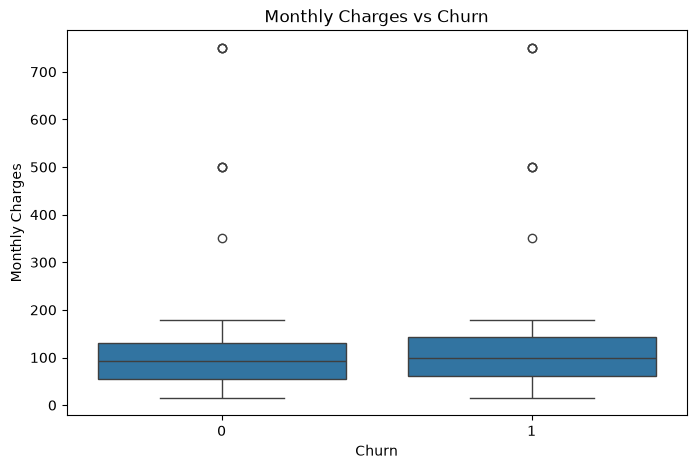

In [54]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="Monthly_Charges")

plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.title("Monthly Charges vs Churn")

plt.savefig('monthly_charges_vs_churn.png',dpi=300,bbox_inches='tight')
plt.show()

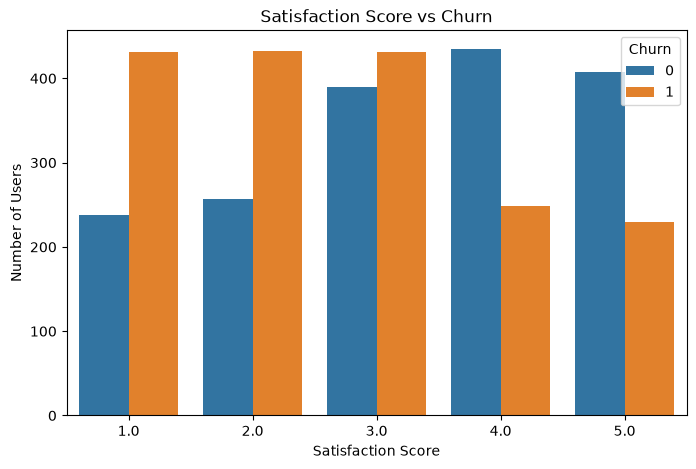

In [55]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Satisfaction_Score", hue="Churn")

plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Users")
plt.title("Satisfaction Score vs Churn")

plt.savefig('satisfaction_vs_churn.png',dpi=300,bbox_inches='tight')
plt.show()

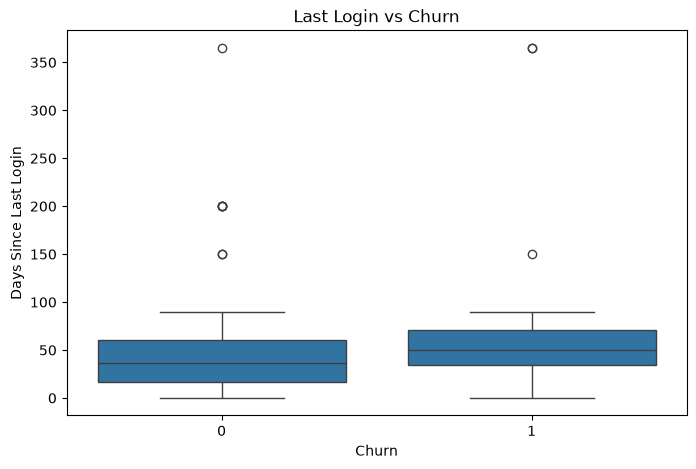

In [56]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="Last_Login_Days_Ago")

plt.xlabel("Churn")
plt.ylabel("Days Since Last Login")
plt.title("Last Login vs Churn")

plt.savefig('last_login_vs_churn.png',dpi=300,bbox_inches='tight')
plt.show()

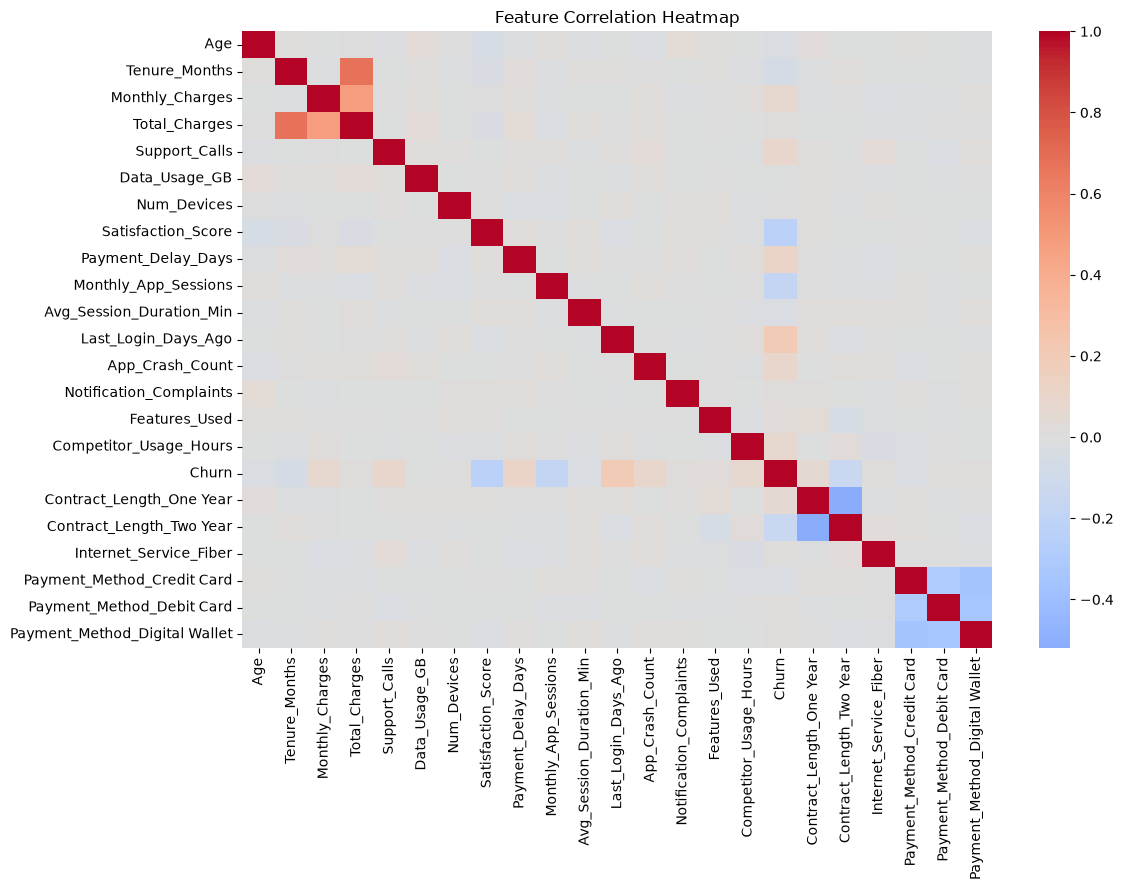

In [57]:
plt.figure(figsize=(12, 9))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()

plt.savefig('correlation_heatmap.png',dpi=300,bbox_inches='tight')
plt.show()

In [58]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3500, 22)
y shape: (3500,)


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2800, 22)
Testing data: (700, 22)


In [60]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
print(X_train_scaled[:5])

[[-1.14741228 -0.21204676  1.39786391  0.97569147  1.35538209 -0.3239714
  -1.5274564   0.75188318 -0.79144899 -1.52978281 -0.84242082  1.24816849
  -0.25843068 -1.21460262 -1.66148636  0.90555392  1.30988927 -0.67588151
   0.68374355 -0.56965192 -0.5288738  -0.65131528]
 [ 0.02939688  0.38148633  0.50830796  0.55680693  1.08057616 -0.57922938
   1.01618457  0.02366702  0.79492931  0.5467975  -0.03781106 -0.37661398
   0.53954672  0.16283251  0.23803359  0.87790922  1.30988927 -0.67588151
   0.68374355 -0.56965192 -0.5288738  -0.65131528]
 [ 0.68317975  0.87609724 -0.56634247 -0.02108855 -0.84306532  1.20998111
  -1.01872821  0.75188318  0.68161657  1.31809876  1.11796314 -1.57754016
  -0.57762164  0.39240503 -0.47428639 -0.52505921 -0.76342331 -0.67588151
   0.68374355 -0.56965192 -0.5288738  -0.65131528]
 [ 1.07544947 -0.16258567  1.11213207  0.91073973 -0.01864755 -0.39943898
  -0.51000001  0.75188318 -0.33819805 -0.40249636 -1.24131634 -0.80047028
   0.85873768  0.39240503  0.71291

In [63]:
k_values = range(1, 21)

accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    knn.fit(X_train_scaled, y_train)
    
    y_pred_k = knn.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred_k)
    accuracies.append(accuracy)

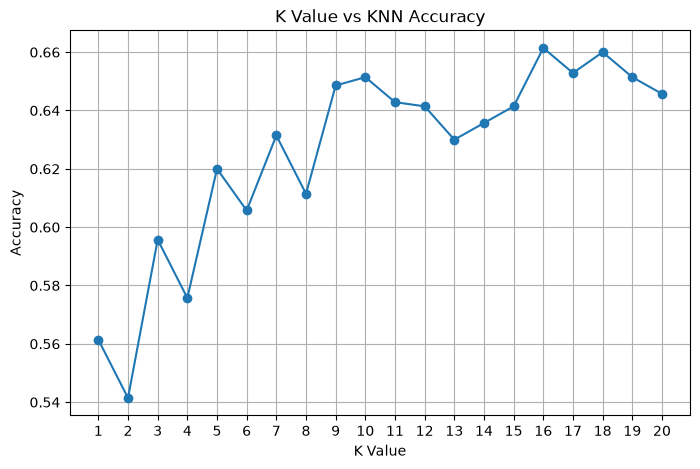

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, accuracies, marker="o")

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K Value vs KNN Accuracy")

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [65]:
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 16
Best Accuracy: 0.6614285714285715


In [66]:
knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

In [68]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.6614285714285715
Precision: 0.6891025641025641
Recall   : 0.6056338028169014
F1 Score : 0.6446776611694153


In [70]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.64      0.72      0.68       345\n           1       0.69      0.61      0.64       355\n\n    accuracy                           0.66       700\n   macro avg       0.66      0.66      0.66       700\nweighted avg       0.66      0.66      0.66       700\n'

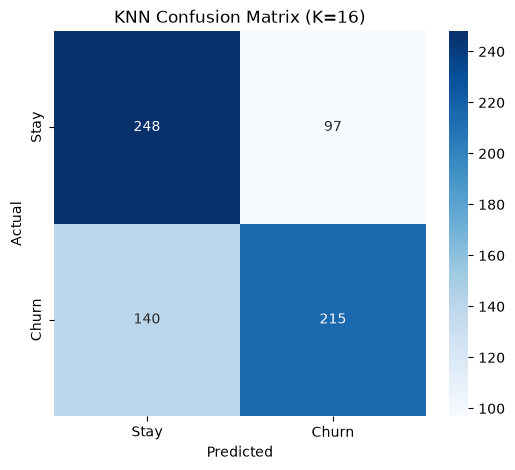

In [71]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Stay", "Churn"],yticklabels=["Stay", "Churn"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"KNN Confusion Matrix (K={best_k})")

plt.show()

In [72]:
k_values = range(1, 21)

accuracy_scores = []
f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred_k = knn.predict(X_test_scaled)

    accuracy_scores.append(accuracy_score(y_test, y_pred_k))

    f1_scores.append(f1_score(y_test, y_pred_k))

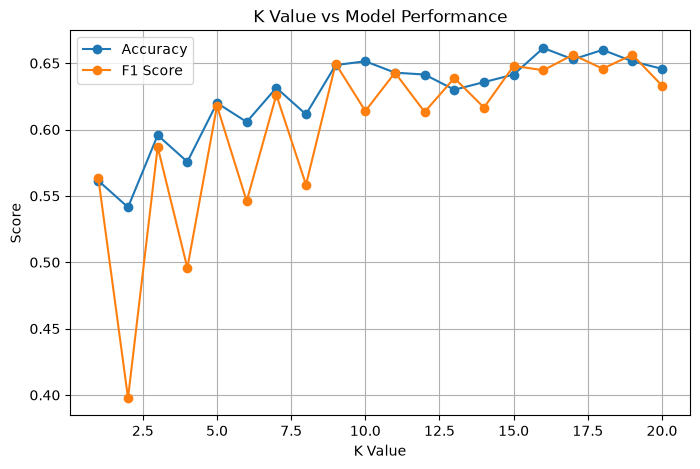

In [76]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, accuracy_scores, marker="o", label="Accuracy")
plt.plot(k_values, f1_scores, marker="o", label="F1 Score")

plt.xlabel("K Value")
plt.ylabel("Score")
plt.title("K Value vs Model Performance")

plt.legend()
plt.grid(True)

plt.savefig('k_value_vs_model_performance.png',dpi=300,bbox_inches='tight')
plt.show()

In [74]:
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))

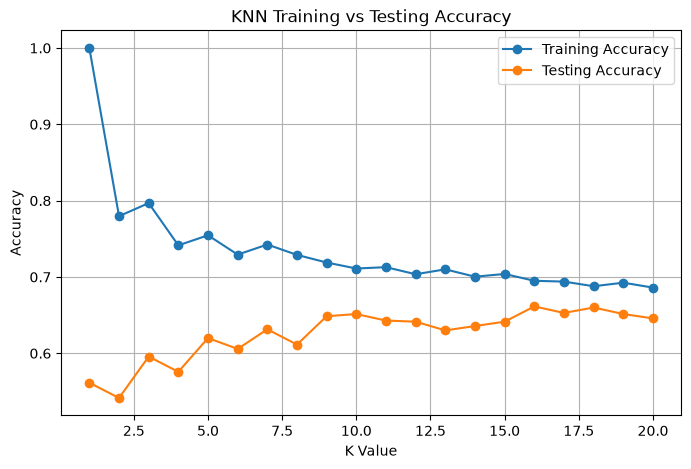

In [75]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, train_scores, marker="o", label="Training Accuracy")
plt.plot(k_values, test_scores, marker="o", label="Testing Accuracy")

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Training vs Testing Accuracy")

plt.legend()
plt.grid(True)

plt.show()